In [1]:
import h5ify
import numpy as np
from util import plot_multiple

In [2]:
datadir = '../../data/inference/strong/multimass/noah'

In [3]:
def wrap_plot_multiple(results, keys, **kwargs):
    xs = []
    for r in results:
        x = []
        for key in keys:
            if key in r:
                x.append(r[key])
            elif 'samples' in r and key in r['samples']:
                x.append(r['samples'][key])
        
        xs.append(np.column_stack(x))

    return plot_multiple(
        xs,
        labels=keys,
        **kwargs
    )

In [44]:
nest = h5ify.load(f'{datadir}/default/nlive1000-var1-stableexpit/posterior.h5')

In [45]:
pt_var1 = h5ify.load(f'{datadir}/default/ptemcee-hybrid-var1/posterior.h5')

In [46]:
pt_var5 = h5ify.load(f'{datadir}/default/ptemcee-hybrid-var5/posterior.h5')

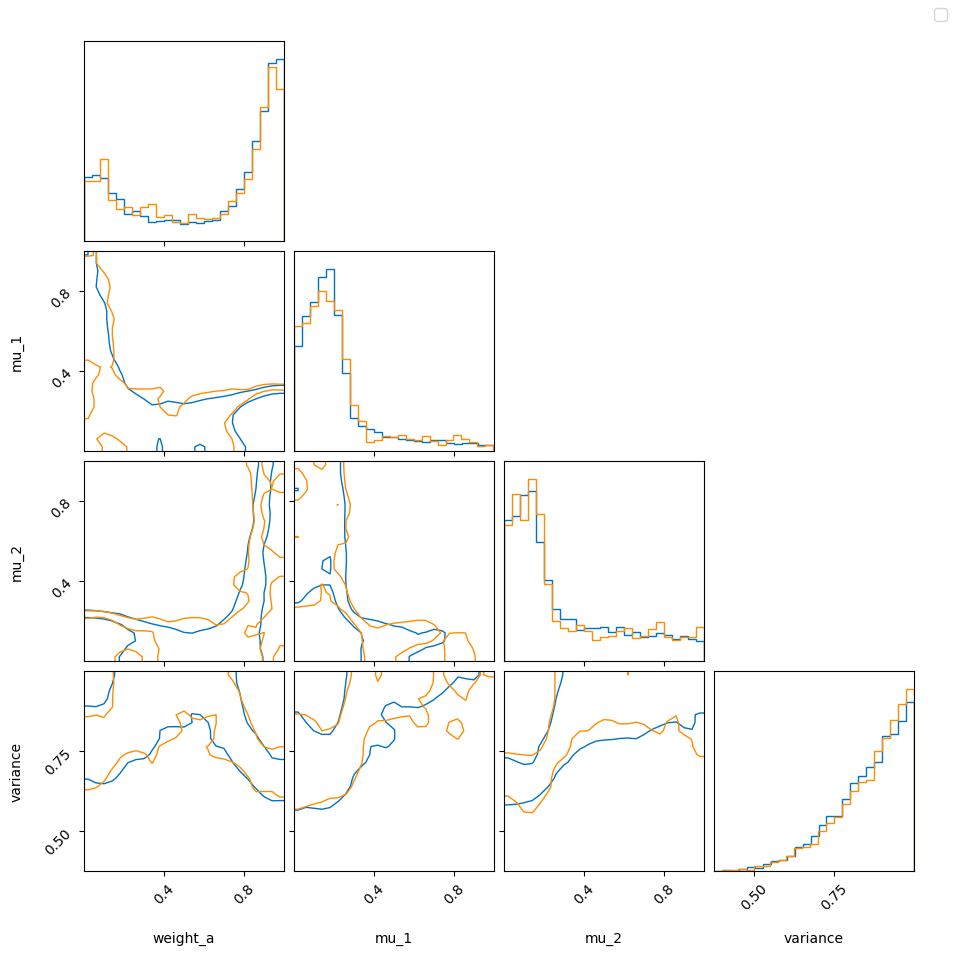

In [47]:
fig = wrap_plot_multiple(
    [nest, pt_var1],
    ['weight_a', 'mu_1', 'mu_2', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

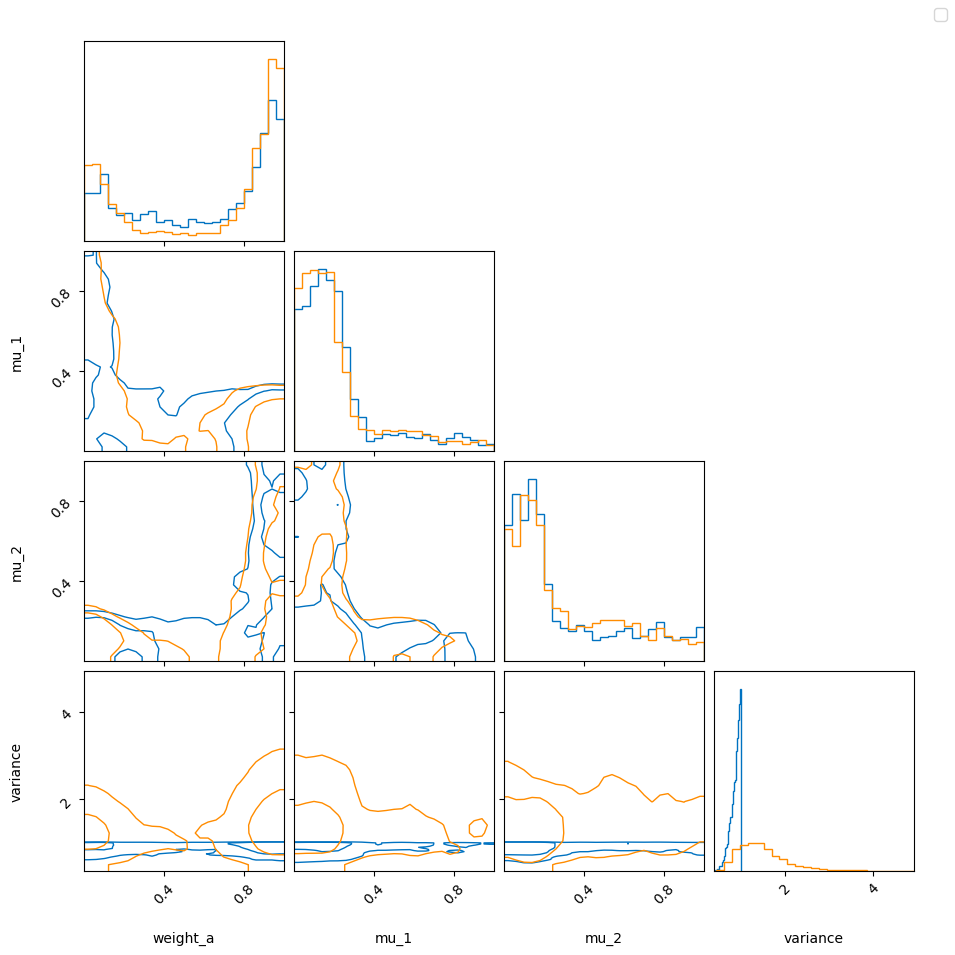

In [48]:
fig = wrap_plot_multiple(
    [pt_var1, pt_var5],
    ['weight_a', 'mu_1', 'mu_2', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

In [65]:
modeldir = f'{datadir}/bpl2p-v1-nlive1000'

nest = h5ify.load(f'{modeldir}/sampling_seed/1701/posterior.h5')

for seed in range(1701, 1711):
    p = h5ify.load(f'{modeldir}/sampling_seed/{seed}/posterior.h5')
    for k in nest.keys():
        if len(np.atleast_1d(nest[k])) > 1:
            nest[k] = np.concatenate((nest[k], p[k]))

In [66]:
pt_var1 = h5ify.load(f'{modeldir}/ptemcee-hybrid-var1/posterior.h5')

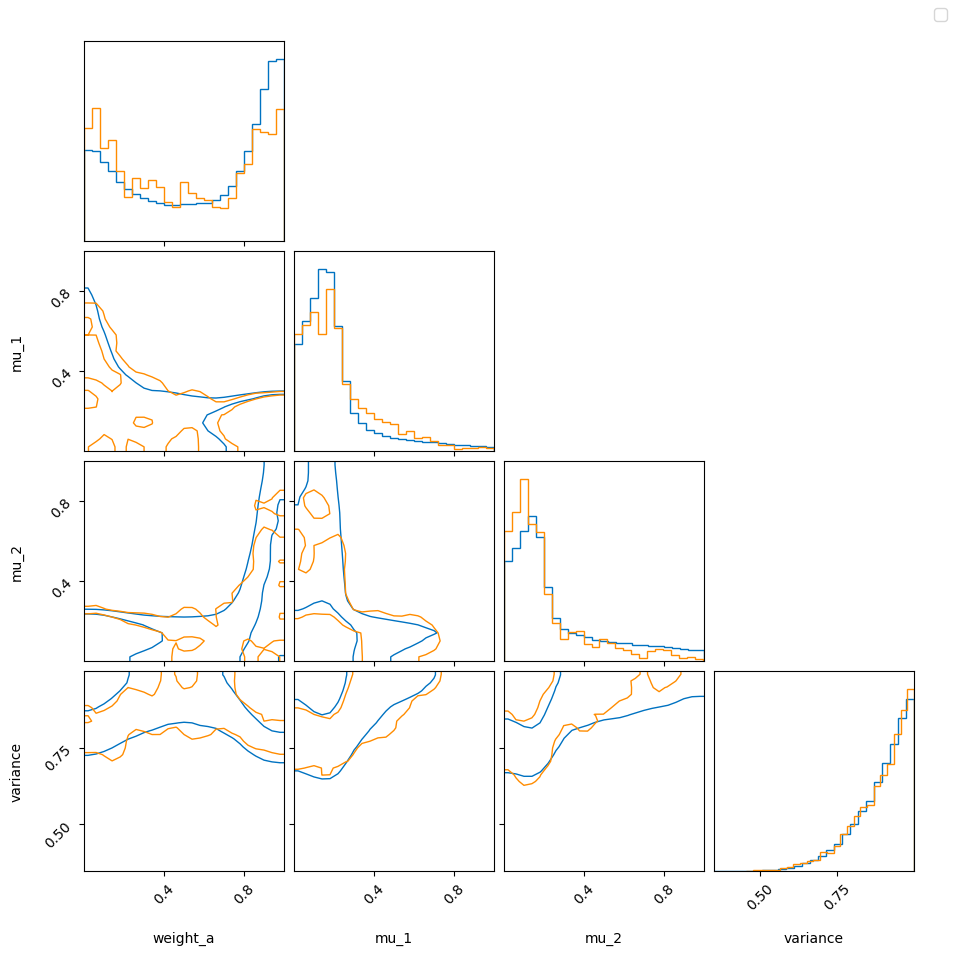

In [67]:
fig = wrap_plot_multiple(
    [nest, pt_var1],
    ['weight_a', 'mu_1', 'mu_2', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

In [68]:
modeldir = f'{datadir}/twomass'

nest = h5ify.load(f'{modeldir}/sampling_seed/1701/posterior.h5')

for seed in range(1701, 1711):
    p = h5ify.load(f'{modeldir}/sampling_seed/{seed}/posterior.h5')
    for k in nest.keys():
        if len(np.atleast_1d(nest[k])) > 1:
            nest[k] = np.concatenate((nest[k], p[k]))

In [69]:
pt_var1 = h5ify.load(f'{modeldir}/ptemcee-hybrid-var1/posterior.h5')

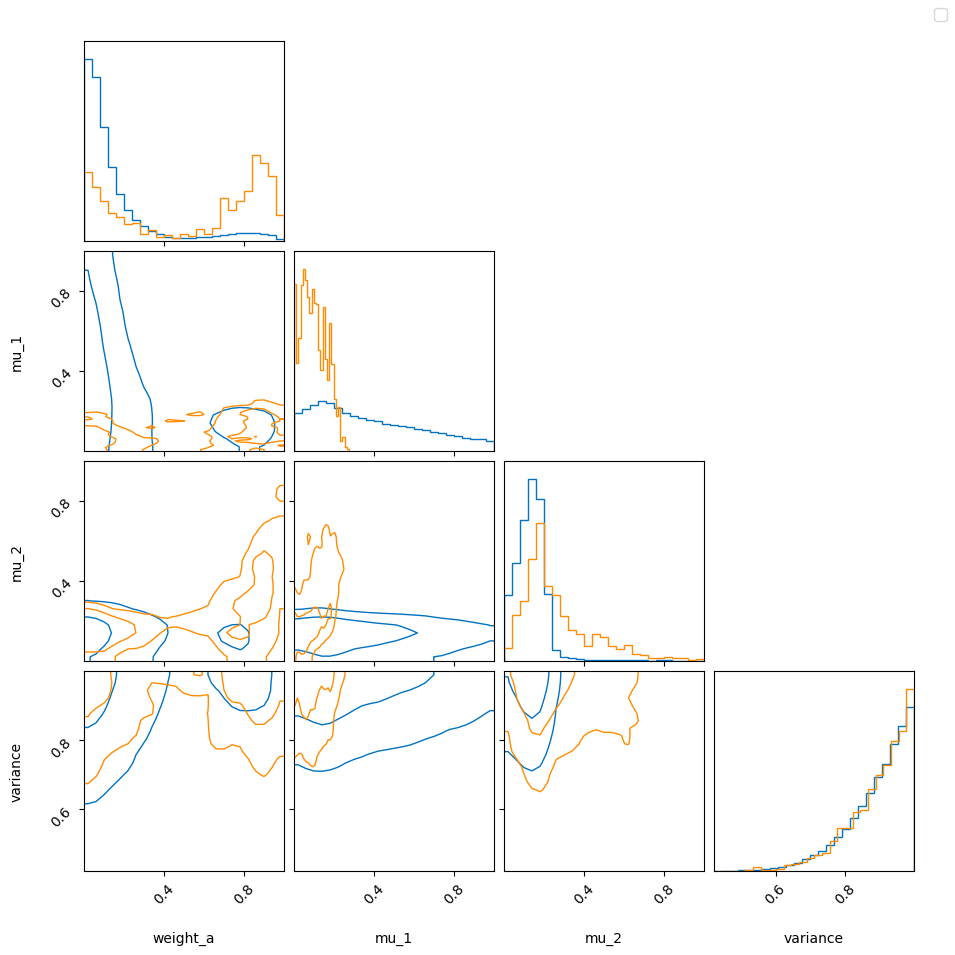

In [70]:
fig = wrap_plot_multiple(
    [nest, pt_var1],
    ['weight_a', 'mu_1', 'mu_2', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

In [71]:
modeldir = f'{datadir}/threemass'

nest = h5ify.load(f'{modeldir}/sampling_seed/1701/posterior.h5')

for seed in range(1701, 1711):
    p = h5ify.load(f'{modeldir}/sampling_seed/{seed}/posterior.h5')
    for k in nest.keys():
        if len(np.atleast_1d(nest[k])) > 1:
            nest[k] = np.concatenate((nest[k], p[k]))

In [72]:
pt_var1 = h5ify.load(f'{modeldir}/ptemcee-hybrid-var1/posterior.h5')

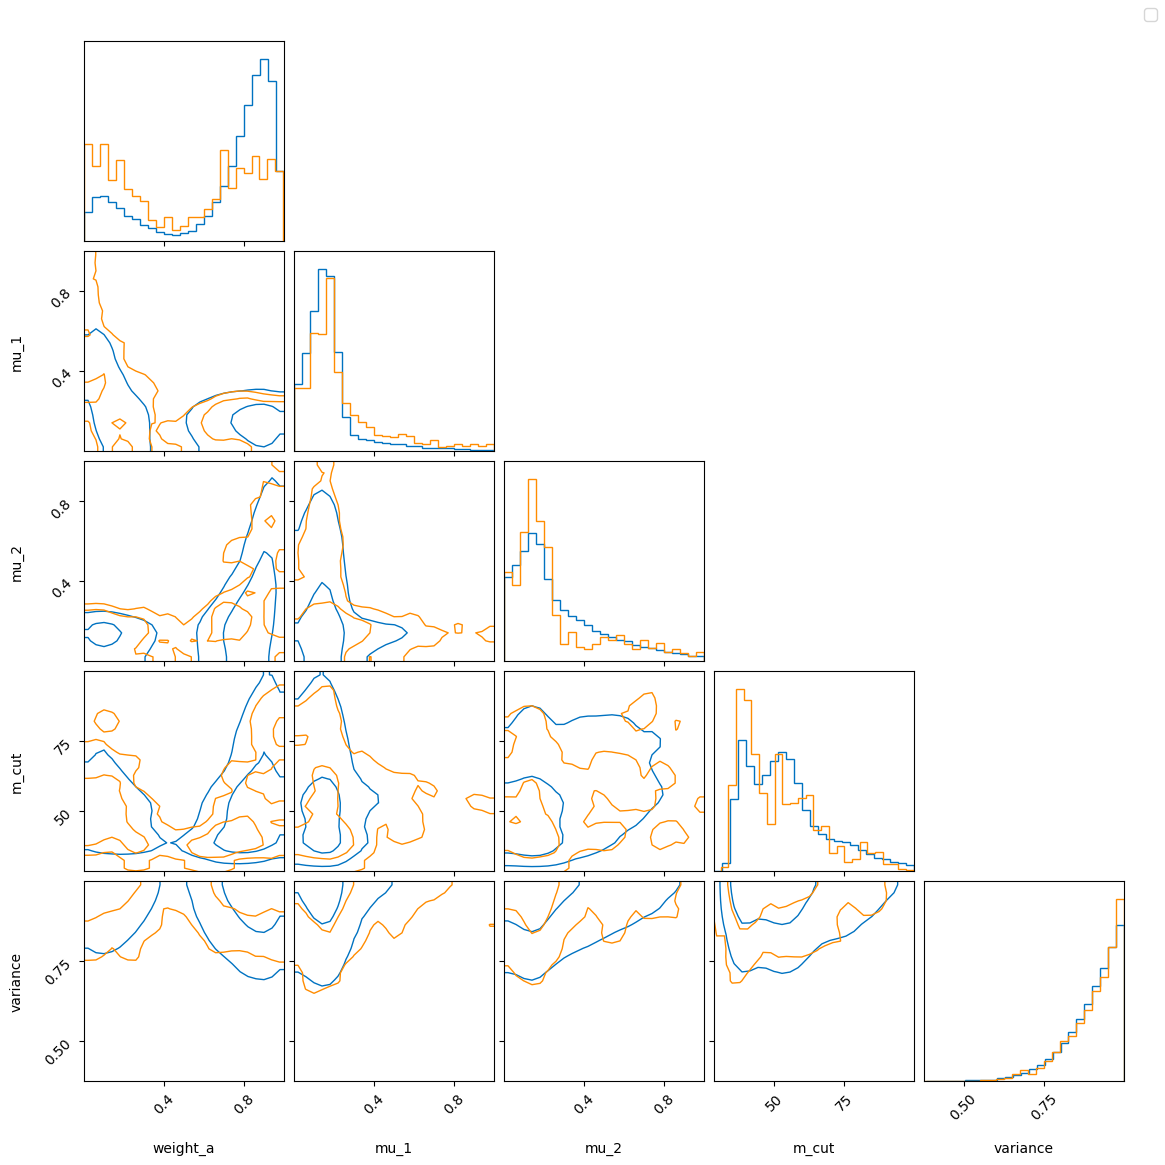

In [74]:
fig = wrap_plot_multiple(
    [nest, pt_var1],
    ['weight_a', 'mu_1', 'mu_2', 'm_cut', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

In [5]:
results_var1 = []
results_var5 = []

for model in ['bpl2p', 'twomass', 'threemass']:
    modeldir = f'{datadir}/{model}'
    pt_var1 = h5ify.load(f'{modeldir}/ptemcee-hybrid-var1/posterior.h5')
    pt_var5 = h5ify.load(f'{modeldir}/ptemcee-hybrid-var5/posterior.h5')
    results_var1.append(pt_var1)
    results_var5.append(pt_var5)

/work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


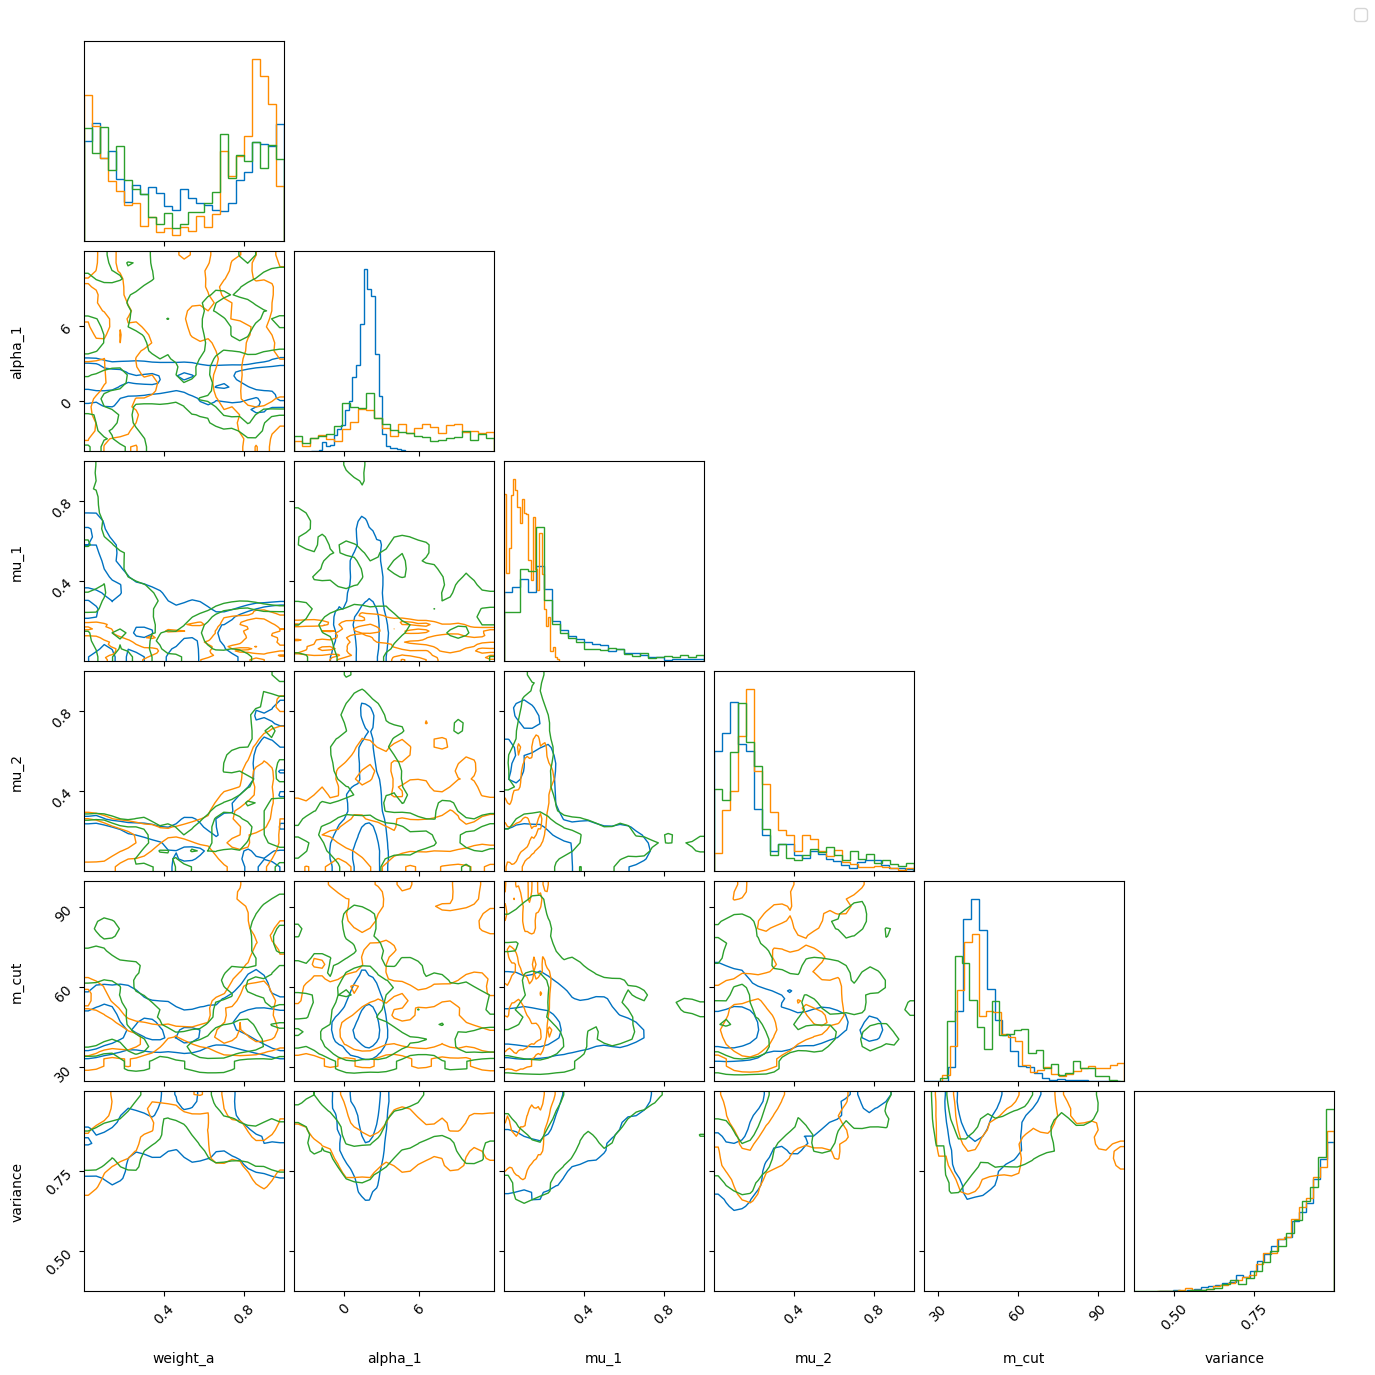

In [6]:
fig = wrap_plot_multiple(
    results_var1,
    ['weight_a', 'alpha_1', 'mu_1', 'mu_2', 'm_cut', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

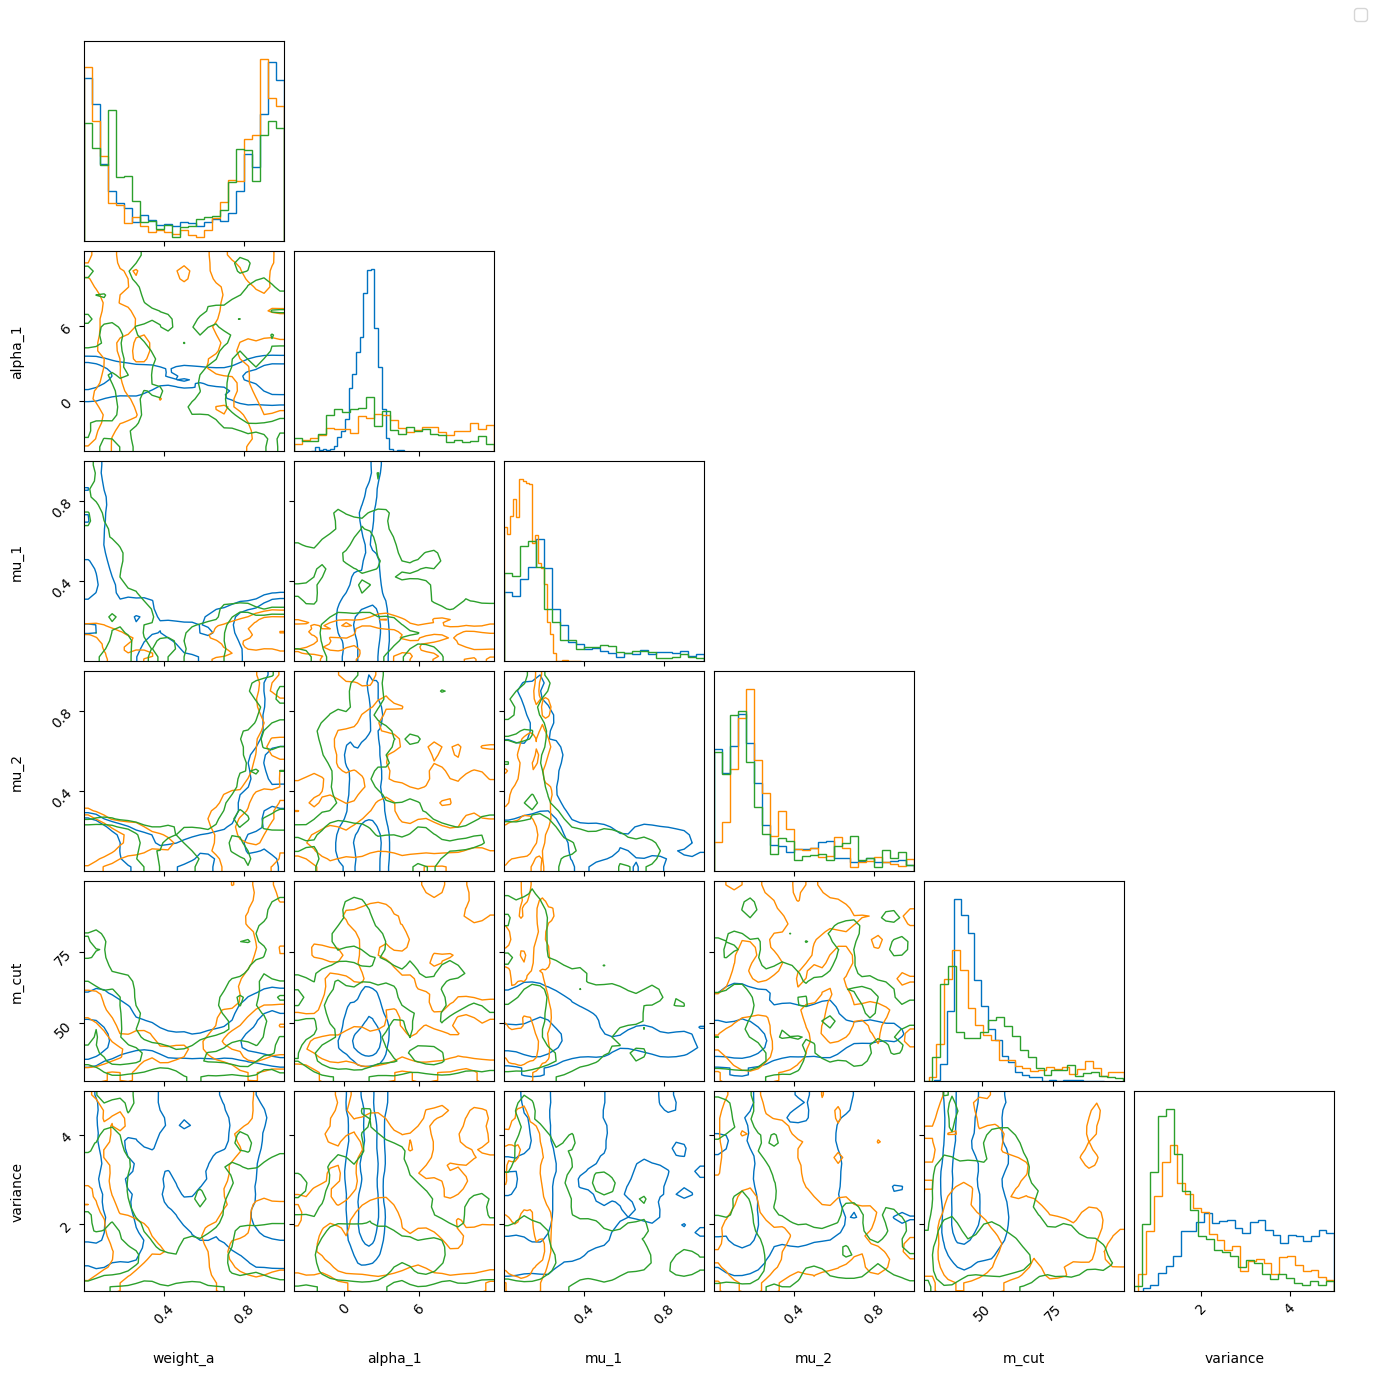

In [7]:
fig = wrap_plot_multiple(
    results_var5,
    ['weight_a', 'alpha_1', 'mu_1', 'mu_2', 'm_cut', 'variance'],
    levels=(0.5, 0.9),
    bins=25,
    no_fill_contours=True,
    fill_contours=False,
    plot_datapoints=False
)

In [7]:
import numpy as np
from bilby.core.result import read_in_result

nest_lnsigma = read_in_result('../../data/inference/strong/multimass/noah/bpl2p-v1-nlive1000/log-sigma-var1/run_result.hdf5')

In [8]:
log_weights = np.log(nest_lnsigma.nested_samples['weights'])

/work/submit/newolfe/miniforge3/envs/just-for-kicks-260228/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [16]:
from arviz import psislw

In [20]:
slw, kss = psislw(np.array(log_weights), normalize=False)

In [155]:
import h5ify

datadir = '../../data/inference/strong/multimass/noah'
modeldir = f'{datadir}/bpl2p-v1-nlive1000'

nest = h5ify.load(f'{modeldir}/sampling_seed/1701/posterior.h5')
seed_results = []

for seed in range(1701, 1711):
    p = h5ify.load(f'{modeldir}/sampling_seed/{seed}/posterior.h5')
    seed_results.append(p)
    for k in nest.keys():
        if len(np.atleast_1d(nest[k])) > 1:
            nest[k] = np.concatenate((nest[k], p[k]))

In [101]:
from bilby.core.prior import Uniform
from bilby.core.prior import ConditionalPriorDict

priors = ConditionalPriorDict('/home/submit/newolfe/projects/tilts-and-kicks/data/inference/strong/multimass/noah/bpl2p-v1-nlive1000/log-sigma-var1/run.prior')

for i in range(1, 4):
    key = f'sigma_{i}'
    priors.pop(f'log_{key}')
    priors[key] = Uniform(minimum=0.1, maximum=1)

In [102]:
samples = nest_lnsigma.posterior.to_dict(orient='list')
samples = {k : np.array(v) for k, v in samples.items() if k in priors}

In [103]:
unif_log_prior = priors.ln_prob(samples, axis=0)

In [104]:
log_weights = unif_log_prior - nest_lnsigma.posterior['log_prior']

In [112]:
bins = np.logspace(np.log10(0.1), 0, 50)
bins

array([0.1       , 0.10481131, 0.10985411, 0.11513954, 0.12067926,
       0.12648552, 0.13257114, 0.13894955, 0.14563485, 0.1526418 ,
       0.15998587, 0.16768329, 0.17575106, 0.184207  , 0.19306977,
       0.20235896, 0.21209509, 0.22229965, 0.23299518, 0.24420531,
       0.25595479, 0.26826958, 0.28117687, 0.29470517, 0.30888436,
       0.32374575, 0.33932218, 0.35564803, 0.37275937, 0.39069399,
       0.40949151, 0.42919343, 0.44984327, 0.47148664, 0.49417134,
       0.51794747, 0.54286754, 0.5689866 , 0.59636233, 0.62505519,
       0.65512856, 0.68664885, 0.71968567, 0.75431201, 0.79060432,
       0.82864277, 0.86851137, 0.91029818, 0.95409548, 1.        ])

In [121]:
nest_lnsigma.posterior['log_sigma_1'].min()

np.float64(-2.2989874593864714)

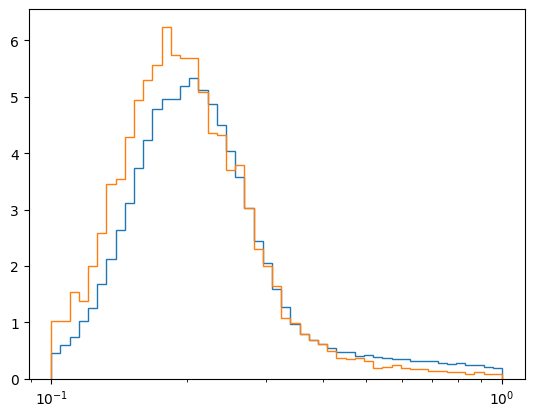

In [126]:
bins = np.logspace(np.log10(0.1), 0, 50)

fig, ax = plt.subplots()
ax.hist((nest['sigma_1']), histtype='step', bins=bins, density=True)
ax.hist(np.exp(nest_lnsigma.posterior['log_sigma_1']), bins=bins, density=True, histtype='step');
ax.semilogx();

In [ ]:
import pickle

with open('/home/submit/newolfe/projects/tilts-and-kicks/data/inference/strong/multimass/noah/bpl2p/log-sigma-var1/run_resume.pickle', 'rb') as f:
    resume = pickle.load(f)

In [165]:
resume[0].n_effective

np.float64(11344.676539153625)

In [172]:
resume[0].__dict__

{'loglikelihood': <dynesty.utils.LogLikelihood at 0x7fcc29d2c8d0>,
 'prior_transform': <dynesty.dynesty._function_wrapper at 0x7fcc2a37a550>,
 'ndim': 23,
 'ncdim': 23,
 'blob': False,
 'live_u': array([[0.35678671, 0.58206571, 0.54523216, ..., 0.78996709, 0.43531747,
         0.39131649],
        [0.30915965, 0.53539995, 0.32721602, ..., 0.80034849, 0.43939622,
         0.43406188],
        [0.29485249, 0.56348163, 0.40468714, ..., 0.84427914, 0.38571571,
         0.32781504],
        ...,
        [0.40900195, 0.64272498, 0.8866906 , ..., 0.7737545 , 0.4466147 ,
         0.41944735],
        [0.374912  , 0.66512489, 0.82821898, ..., 0.824414  , 0.43721089,
         0.39382873],
        [0.34567419, 0.54668914, 0.54811609, ..., 0.82161888, 0.40490886,
         0.36876023]], shape=(1000, 23)),
 'live_v': array([[ 1.70858733,  5.3130513 , 36.3569648 , ...,  0.78996709,
         49.17857228,  3.30448137],
        [ 0.9465544 ,  4.56639922, 29.81648054, ...,  0.80034849,
         49.545660

In [171]:
resume[0].live_it

array([32668, 31031, 31540, 32444, 30189, 32256, 32198, 32094, 31633,
       33046, 32412, 32773, 32678, 30419, 32962, 31556, 32631, 32983,
       31774, 31935, 32853, 32313, 32507, 30922, 32431, 32199, 30762,
       32855, 32063, 32458, 31600, 32860, 32459, 30580, 33002, 33013,
       32511, 32167, 32874, 32882, 31185, 30656, 32720, 32319, 31479,
       32802, 31058, 33031, 30357, 31912, 32229, 32681, 30745, 32664,
       32884, 31803, 32864, 33025, 32987, 31217, 31101, 32873, 30396,
       32581, 31582, 32896, 32644, 29536, 30260, 31814, 32571, 29970,
       33037, 32187, 32711, 30792, 31921, 33026, 32588, 32776, 31583,
       32132, 32430, 32702, 32731, 32657, 32898, 32155, 32739, 32263,
       32131, 32045, 30601, 32295, 32639, 32509, 32894, 31875, 32919,
       31823, 31733, 32433, 31391, 29675, 31670, 31398, 32726, 31113,
       32405, 32255, 32875, 32434, 32368, 32892, 32934, 32069, 30267,
       32086, 32654, 32920, 31828, 32279, 30602, 32059, 31607, 31263,
       32538, 30746,

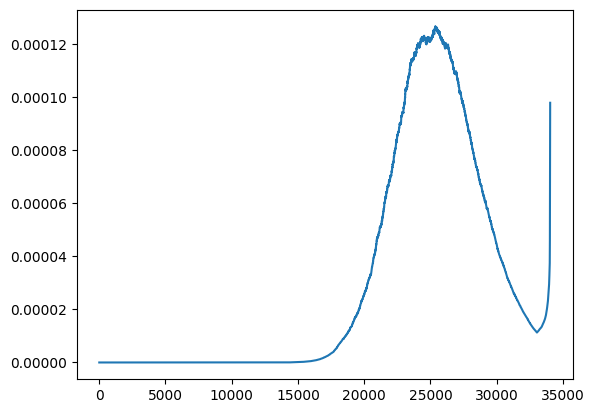

In [173]:
fig, ax = plt.subplots()

ax.plot(
    nest_lnsigma.nested_samples['weights']
)

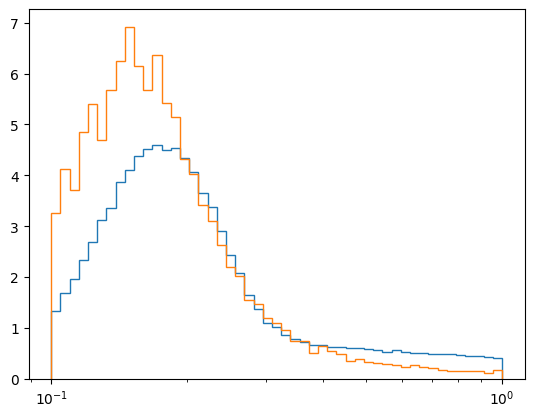

In [129]:
bins = np.logspace(np.log10(0.1), 0, 50)

fig, ax = plt.subplots()
ax.hist((nest['sigma_2']), histtype='step', bins=bins, density=True)
ax.hist(np.exp(nest_lnsigma.posterior['log_sigma_2']), bins=bins, density=True, histtype='step');
ax.semilogx();

In [144]:
nest_lnsigma_with_var = h5ify.load('/home/submit/newolfe/projects/tilts-and-kicks/data/inference/strong/multimass/noah/bpl2p-v1-nlive1000/log-sigma-var1/posterior.h5')

In [151]:
nest_lnsigma_with_var5 = h5ify.load('/home/submit/newolfe/projects/tilts-and-kicks/data/inference/strong/multimass/noah/bpl2p-v1-nlive1000/log-sigma-var5/posterior.h5')

In [147]:
nest['log_sigma_1'] = np.log(nest['sigma_1'])
nest['log_sigma_2'] = np.log(nest['sigma_2'])

ValueError: Provided figure has 25 axes, but data has dimensions K=7

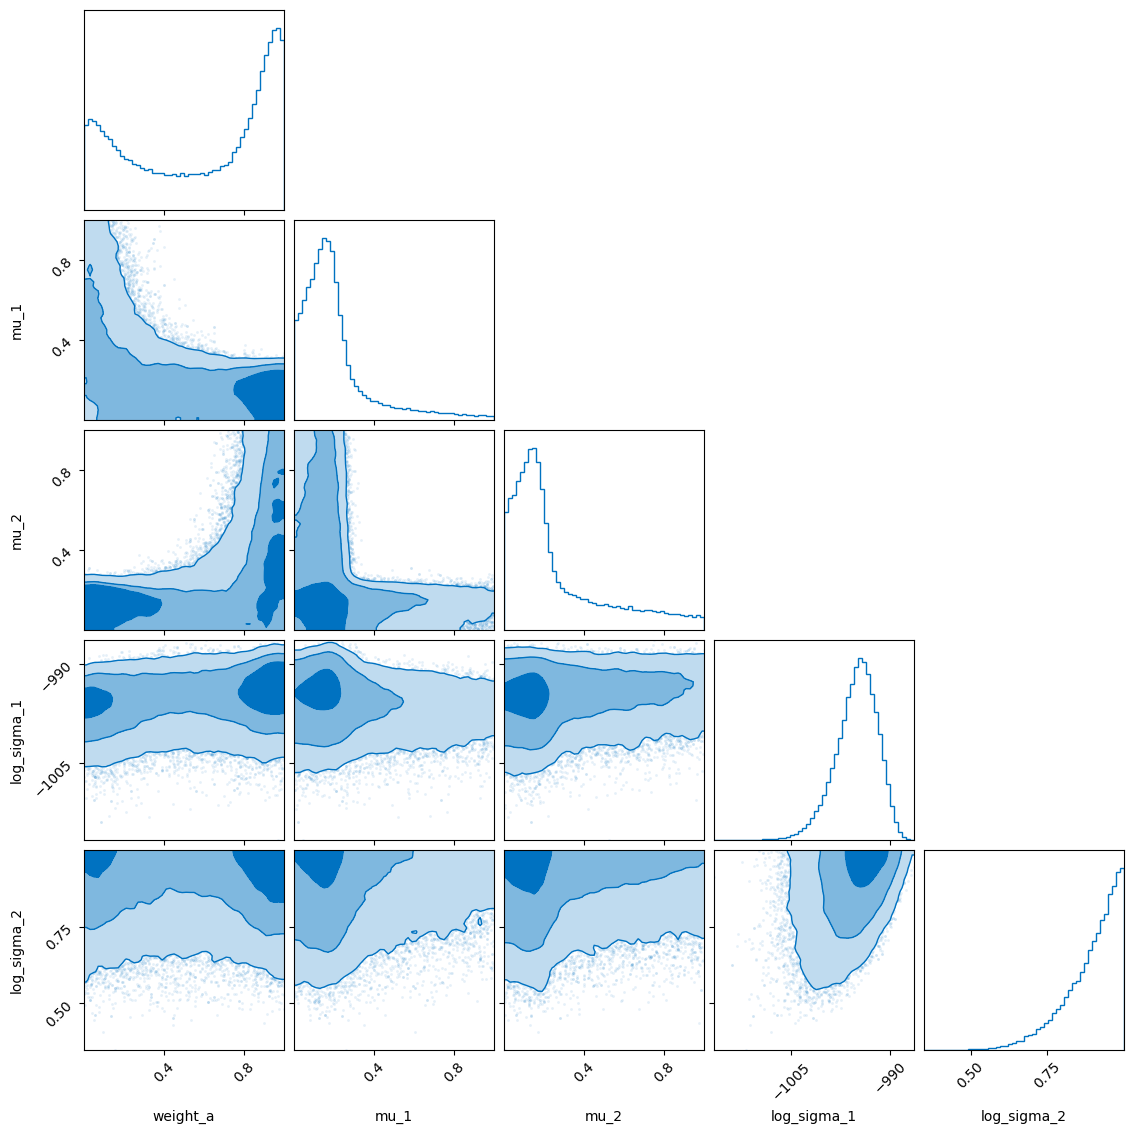

In [ ]:
from util import plot_multiple

keys = ['weight_a', 'mu_1', 'mu_2', 'log_sigma_1', 'log_sigma_2', 'log_likelihood', 'variance']

fig = wrap_plot_multiple(
    [
        nest,
        nest_lnsigma_with_var,
        seed_results[0]
    ],
    keys
);

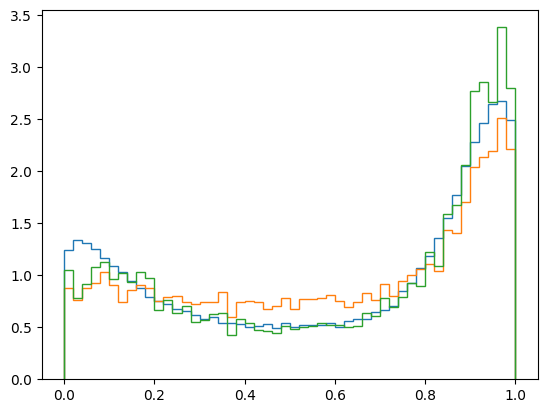

In [175]:
fig, ax = plt.subplots()

ax.hist(
    nest['weight_a'],
    histtype='step',
    bins=50,
    density=True,
    #weights=np.exp(log_weights - log_weights.max())
);


ax.hist(
    nest_lnsigma.posterior['weight_a'],
    histtype='step',
    bins=50,
    density=True,
    #weights=np.exp(log_weights - log_weights.max())
);

ax.hist(
    nest_lnsigma.posterior['weight_a'],
    histtype='step',
    bins=50,
    density=True,
    weights=np.exp(nest_lnsigma.posterior['log_sigma_1'] + nest_lnsigma.posterior['log_sigma_2'] + nest_lnsigma.posterior['log_sigma_3'] )
);

In [73]:
unif_log_prior

array([-35.80058761, -32.90055249, -32.71943845, ..., -32.52945098,
       -33.27146886, -32.61930922], shape=(7898,))

In [74]:
nest_lnsigma.posterior['log_prior']

0      -38.302685
1      -35.402650
2      -35.221536
3      -35.357226
4      -34.686369
          ...    
7893   -34.945193
7894   -34.522208
7895   -35.031548
7896   -35.773566
7897   -35.121407
Name: log_prior, Length: 7898, dtype: float64

In [72]:
log_weights

0       2.502097
1       2.502097
2       2.502097
3       2.502097
4       2.502097
          ...   
7893    2.502097
7894    2.502097
7895    2.502097
7896    2.502097
7897    2.502097
Name: log_prior, Length: 7898, dtype: float64

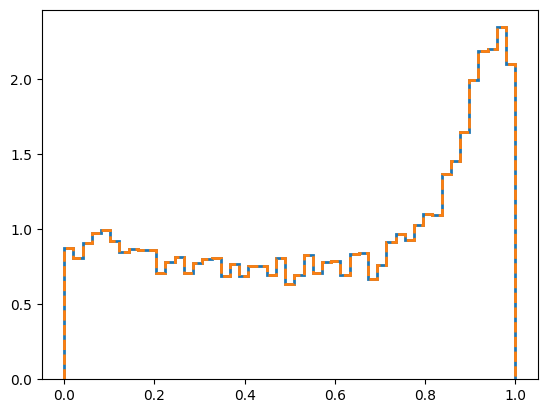

In [50]:
bins = np.linspace(0, 1, 50)

fig, ax = plt.subplots()
ax.hist(
    nest_lnsigma.nested_samples['weight_a'],
    weights=np.exp(log_weights - log_weights.max()),
    bins=bins,
    histtype='step',
    density=True,
    lw=2
)

ax.hist(
    nest_lnsigma.nested_samples['weight_a'],
    weights=np.exp(slw - slw.max()),
    bins=bins,
    histtype='step',
    density=True,
    linestyle='--',
    lw=2
);

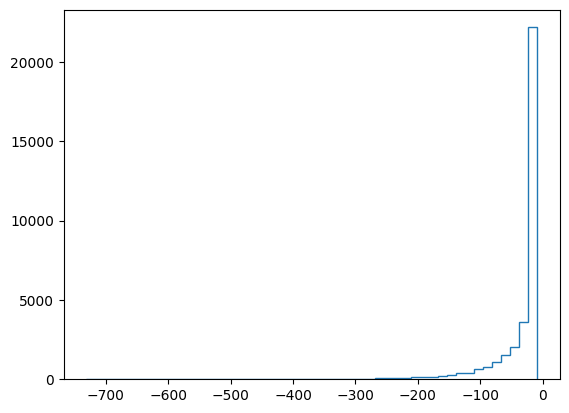

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.hist(log_weights[np.isfinite(log_weights)], histtype='step', bins=50);